In [19]:
from PIL import Image
import math
import os
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
card_w = 63
card_h = 88
margin = 3.175

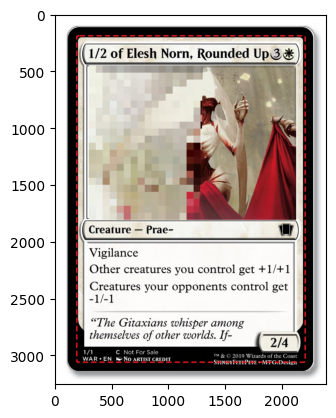

In [ ]:
image_path = (Path(os.path.abspath('')).parent / "downloads") / "draftable_upscaled/1_2_of_Elesh_Norn_Rounded_Up.png"
reference_border = Image.open(Path(os.path.abspath('')).parent / "MPCReference.png")
img = Image.open(image_path)
width, height = img.size
bleed_pixels_h = math.ceil(margin/card_h * height)
bleed_pixels_w = math.ceil(margin/card_w * width)
image_array = np.array(list(img.getdata())).reshape((height,width,4))[:,:,:-1]
top_bleed = np.repeat(image_array[0,...].T,repeats=bleed_pixels_w).reshape((bleed_pixels_w,width,3))
bottom_bleed = np.repeat(image_array[-1,...].T,repeats=bleed_pixels_w).reshape((bleed_pixels_w,width,3))
image_array = np.concatenate((top_bleed, image_array, bottom_bleed))
height = image_array.shape[0]
left_bleed = np.repeat(image_array[:,0,...],repeats=bleed_pixels_h).reshape((height,bleed_pixels_h,3))
right_bleed = np.repeat(image_array[:,-1,...],repeats=bleed_pixels_h).reshape((height,bleed_pixels_h,3))
image_array = np.concatenate((left_bleed, image_array, right_bleed),axis=1)
plt.imshow(image_array)
# reference_border = reference_border.resize((image_array.shape[1],image_array.shape[0]))
# plt.imshow(reference_border)

In [57]:
img_w_bleed = Image.fromarray(np.uint8(image_array))
img_w_bleed.save("TestBleed.png")